<a href="https://colab.research.google.com/github/vyasamayuri/11239A102_opencv/blob/main/exp9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving Screenshot 2026-04-16 212410.png to Screenshot 2026-04-16 212410.png


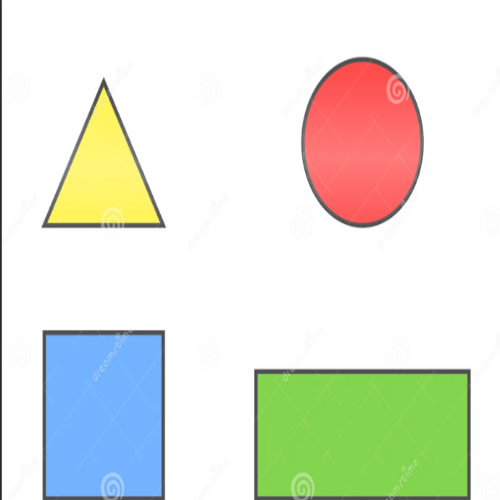

In [ ]:
# Step 4: Read Image
img = cv2.imread('Screenshot 2026-04-16 212410.png')   # change if needed
img = cv2.resize(img, (500, 500))
cv2_imshow(img)

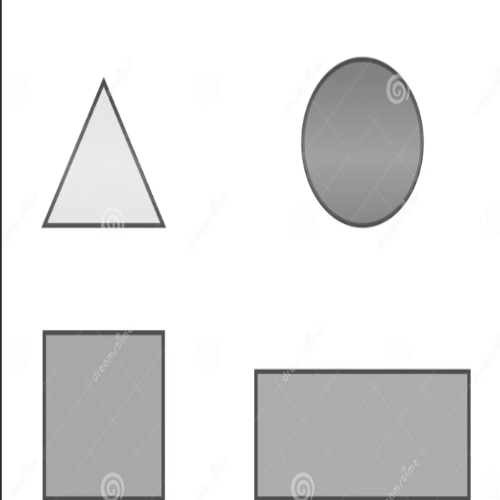

In [ ]:
# Step 5: Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

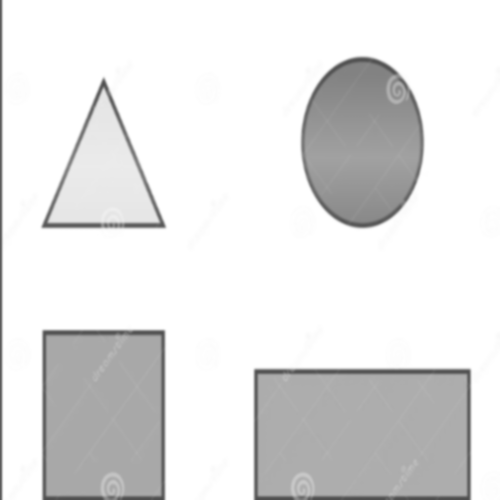

In [ ]:
# Step 6: Apply Gaussian Blur
blur = cv2.GaussianBlur(gray, (5, 5), 0)
cv2_imshow(blur)


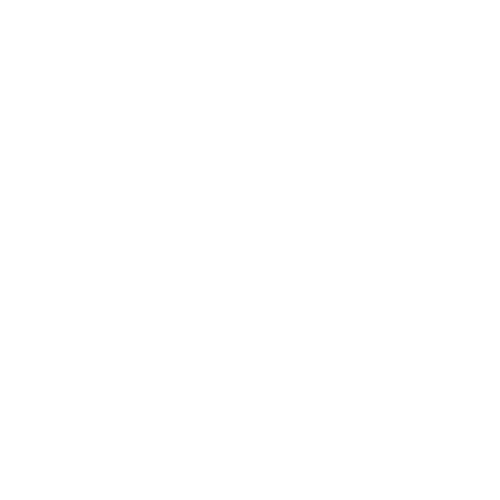

In [ ]:
 # Step 7: Apply Thresholding
_, thresh = cv2.threshold(blur, 60, 255, cv2.THRESH_BINARY)
cv2_imshow(thresh)

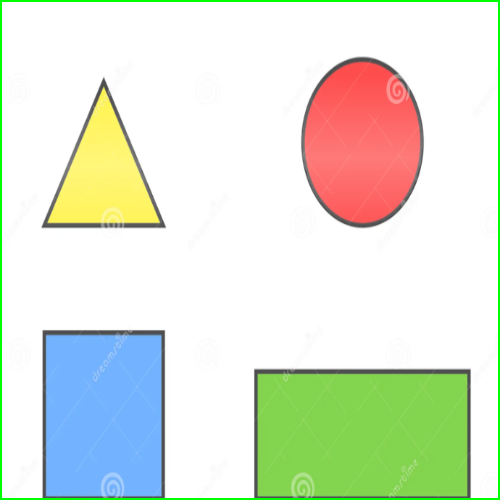

In [ ]:
# Step 8: Detect Contours
contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Optional: draw all contours
temp = img.copy()
cv2.drawContours(temp, contours, -1, (0, 255, 0), 2)
cv2_imshow(temp)

In [ ]:
# Step 9: Shape Detection & Labeling
for cnt in contours:
    approx = cv2.approxPolyDP(cnt, 0.04 * cv2.arcLength(cnt, True), True)

    x = approx.ravel()[0]
    y = approx.ravel()[1]

    if len(approx) == 3:
        shape = "Triangle"
    elif len(approx) == 4:
        shape = "Rectangle"
    elif len(approx) >= 5:   # FIXED CONDITION
        shape = "Circle"
    else:
        shape = "Unknown"

    # Draw contour
    cv2.drawContours(img, [approx], 0, (0, 255, 0), 3)

    # Put label
    cv2.putText(img, shape, (x, y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (255, 0, 0), 2)

In [ ]:
# Step 9: Shape Detection & Labeling
for cnt in contours:
    approx = cv2.approxPolyDP(cnt, 0.04 * cv2.arcLength(cnt, True), True)

    x = approx.ravel()[0]
    y = approx.ravel()[1]

    if len(approx) == 3:
        shape = "Triangle"
    elif len(approx) == 4:
        shape = "Rectangle"
    elif len(approx) >= 5:   # FIXED CONDITION
        shape = "Circle"
    else:
        shape = "Unknown"

    # Draw contour
    cv2.drawContours(img, [approx], 0, (0, 255, 0), 3)

    # Put label
    cv2.putText(img, shape, (x, y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (255, 0, 0), 2)

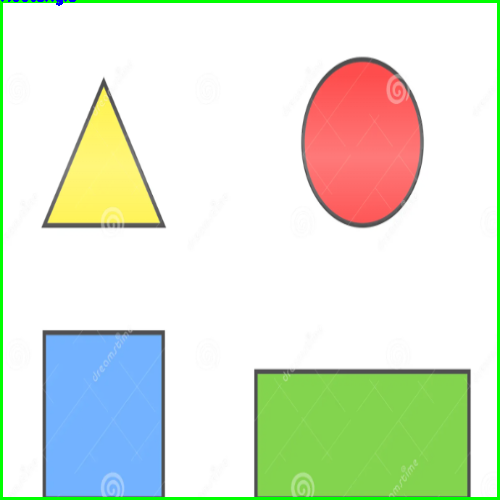

In [ ]:
# Step 10: Display Final Output
cv2_imshow(img)
